Loading flight data...
  2004: 7,129,270 rows loaded
  2005: 7,140,596 rows loaded
  2006: 7,141,922 rows loaded
  2007: 7,453,215 rows loaded
  2008: 2,389,217 rows loaded

Total rows across all years: 31,254,220

Rows after removing cancelled flights: 30,645,609

PART 2(a): Best times and days to minimise delays


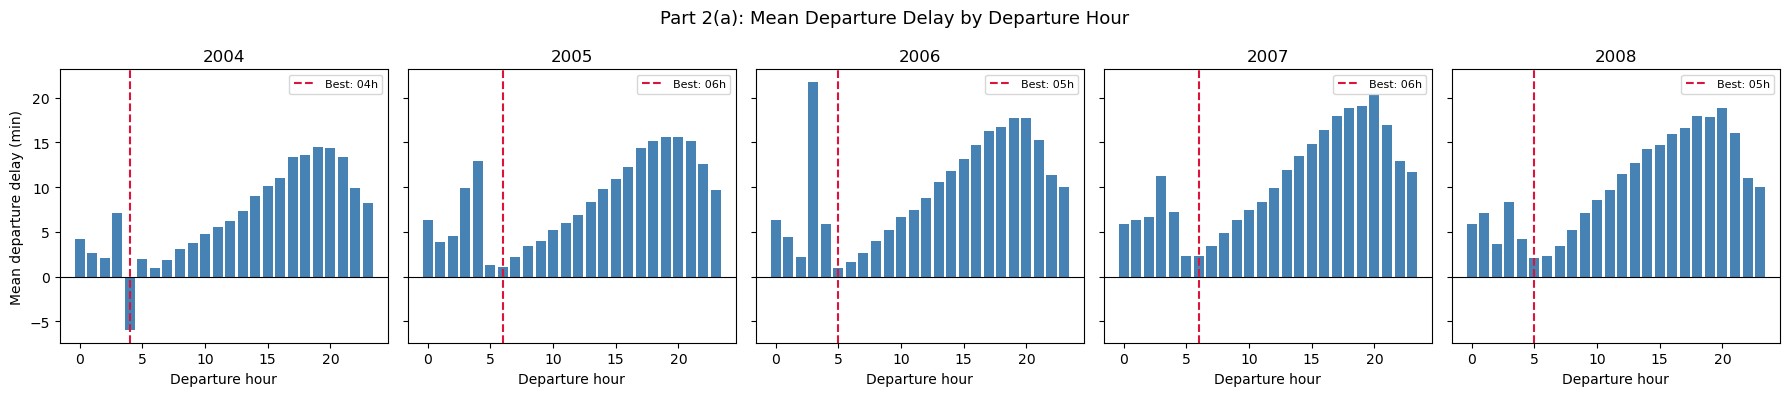

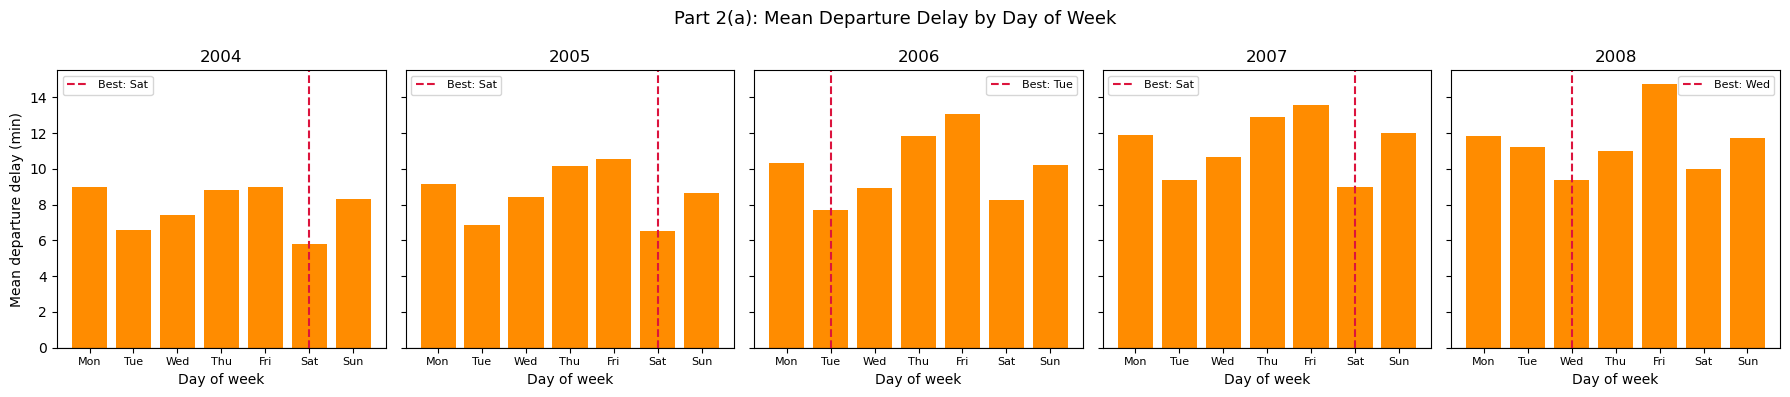

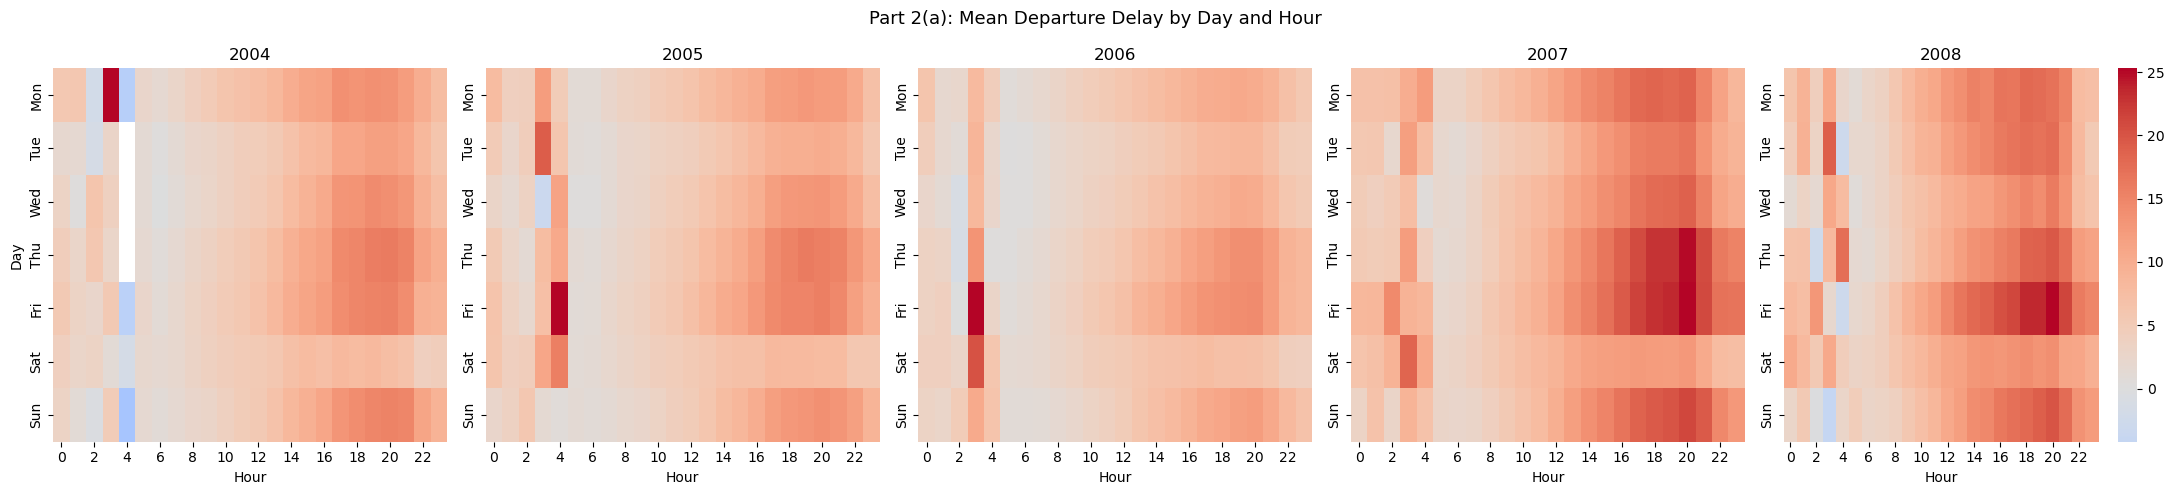


Summary – best departure hour and day per year:
Year   Best Hour    Delay (min)    Best Day   Delay (min)
-------------------------------------------------------
2004   04:00        -6.0           Sat        5.8
2005   06:00        1.1            Sat        6.6
2006   05:00        1.0            Tue        7.7
2007   06:00        2.3            Sat        9.0
2008   05:00        2.1            Wed        9.4

PART 2(b): Older planes and delays


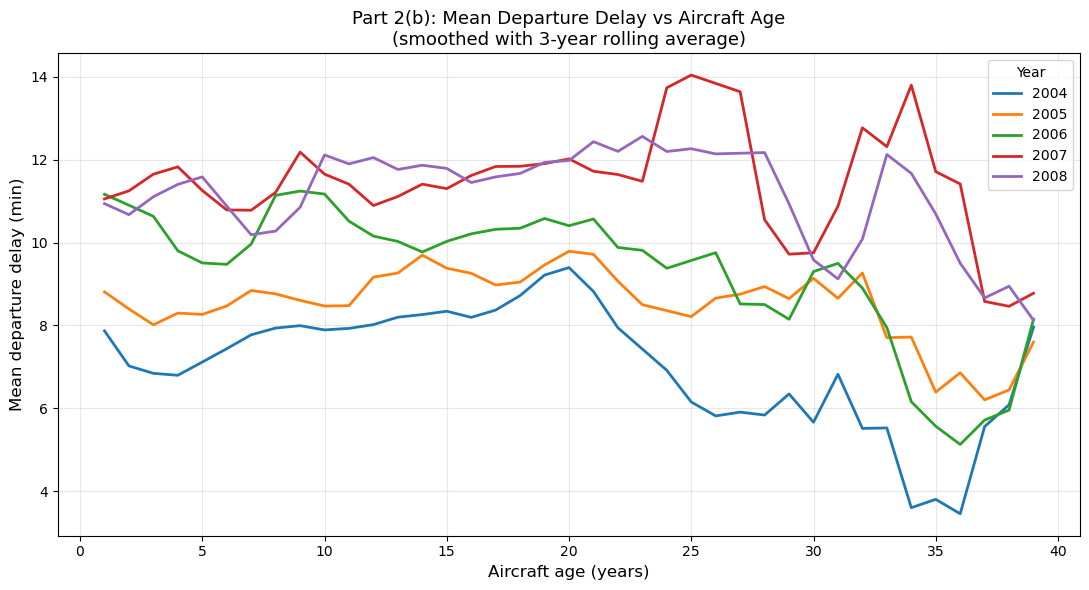


Correlation between plane age and departure delay (per year):
(closer to +1 = older planes more delayed, closer to 0 = no relationship)
--------------------------------------------------
  2004: Pearson r = 0.0024
  2005: Pearson r = 0.0046
  2006: Pearson r = -0.0088
  2007: Pearson r = 0.0004
  2008: Pearson r = 0.0074

PART 2(c): Logistic regression for P(Diverted)
  2004: model fitted on 7,001,512 flights | 19 carriers included
  2005: model fitted on 7,006,866 flights | 20 carriers included
  2006: model fitted on 7,019,988 flights | 20 carriers included
  2007: model fitted on 7,292,467 flights | 20 carriers included
  2008: model fitted on 2,324,775 flights | 20 carriers included


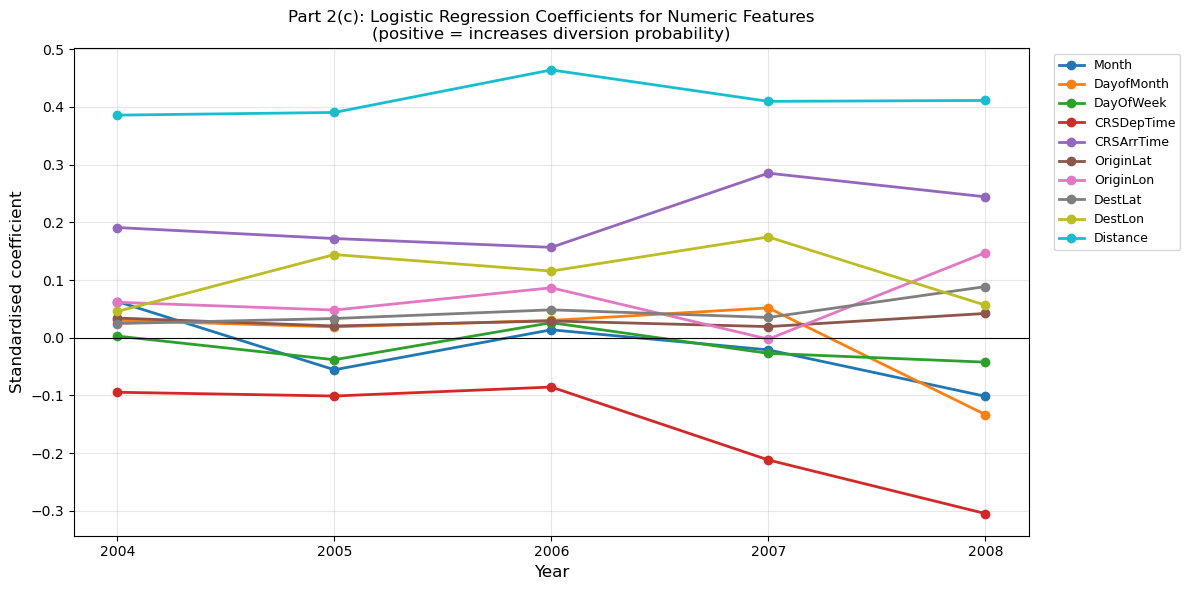

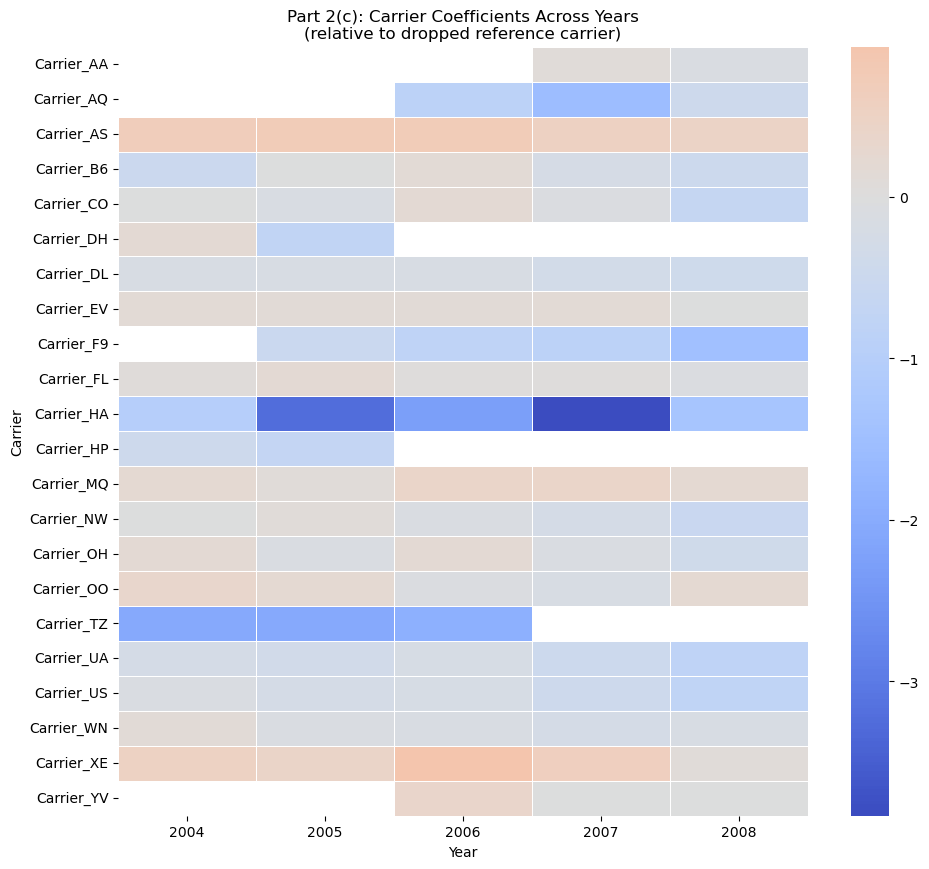


All plots saved. Analysis complete.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

FLIGHT_COLS = [
    "Year", "Month", "DayofMonth", "DayOfWeek",
    "DepTime", "CRSDepTime", "CRSArrTime",
    "ArrDelay", "DepDelay", "UniqueCarrier",
    "TailNum", "Origin", "Dest", "Distance",
    "Diverted", "Cancelled"
]

DATA_DIR = r"C:\Users\kenni\OneDrive\Desktop\Attachments\plane"

print("Loading flight data...")
frames = []
for yr in [2004, 2005, 2006, 2007, 2008]:
    path = f"{DATA_DIR}/{yr}.csv.bz2"
    chunk = pd.read_csv(path, usecols=FLIGHT_COLS)
    frames.append(chunk)
    print(f"  {yr}: {len(chunk):,} rows loaded")

df = pd.concat(frames, ignore_index=True)
print(f"\nTotal rows across all years: {len(df):,}\n")

airports = pd.read_csv(
    f"{DATA_DIR}/airports.csv",
    usecols=["iata", "lat", "long"]
)
airports.columns = ["iata", "lat", "lon"]  

planes = pd.read_csv(
    f"{DATA_DIR}/plane-data.csv",
    usecols=["tailnum", "year"]
)
planes["year"] = pd.to_numeric(planes["year"], errors="coerce")
planes.rename(columns={"year": "MfgYear"}, inplace=True)

df = df[df["Cancelled"] == 0].copy()
print(f"Rows after removing cancelled flights: {len(df):,}\n")

df["Hour"] = (df["CRSDepTime"] // 100).astype("Int16")

df["Year"]      = df["Year"].astype("int16")
df["Month"]     = df["Month"].astype("int8")
df["DayofMonth"]= df["DayofMonth"].astype("int8")
df["DayOfWeek"] = df["DayOfWeek"].astype("int8")
df["Distance"]  = df["Distance"].astype("int16")
df["Diverted"]  = df["Diverted"].astype("int8")

df["ArrDelay"] = pd.to_numeric(df["ArrDelay"], errors="coerce")
df["DepDelay"] = pd.to_numeric(df["DepDelay"], errors="coerce")

YEARS = [2004, 2005, 2006, 2007, 2008]

DAY_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

print("=" * 55)
print("PART 2(a): Best times and days to minimise delays")
print("=" * 55)

df_delay = df.dropna(subset=["DepDelay"])

hour_delay = (
    df_delay
    .groupby(["Year", "Hour"])["DepDelay"]
    .mean()
    .reset_index()
    .rename(columns={"DepDelay": "MeanDelay"})
)

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
for ax, yr in zip(axes, YEARS):
    sub = hour_delay[hour_delay["Year"] == yr]
    ax.bar(sub["Hour"], sub["MeanDelay"], color="steelblue", edgecolor="none")
    ax.axhline(0, color="black", lw=0.8)  
    ax.set_title(str(yr))
    ax.set_xlabel("Departure hour")
    if ax == axes[0]:
        ax.set_ylabel("Mean departure delay (min)")
    best_hr = sub.loc[sub["MeanDelay"].idxmin(), "Hour"]
    ax.axvline(best_hr, color="crimson", lw=1.5, ls="--",
               label=f"Best: {int(best_hr):02d}h")
    ax.legend(fontsize=8)
fig.suptitle("Part 2(a): Mean Departure Delay by Departure Hour", fontsize=13)
plt.tight_layout()
plt.savefig("part2a_hour_delay.png", dpi=150)
plt.show()

day_delay = (
    df_delay
    .groupby(["Year", "DayOfWeek"])["DepDelay"]
    .mean()
    .reset_index()
    .rename(columns={"DepDelay": "MeanDelay"})
)

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
for ax, yr in zip(axes, YEARS):
    sub = day_delay[day_delay["Year"] == yr]
    ax.bar(sub["DayOfWeek"], sub["MeanDelay"], color="darkorange", edgecolor="none")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(range(1, 8))
    ax.set_xticklabels(DAY_LABELS, fontsize=8)
    ax.set_title(str(yr))
    ax.set_xlabel("Day of week")
    if ax == axes[0]:
        ax.set_ylabel("Mean departure delay (min)")
    best_day = sub.loc[sub["MeanDelay"].idxmin(), "DayOfWeek"]
    ax.axvline(best_day, color="crimson", lw=1.5, ls="--",
               label=f"Best: {DAY_LABELS[int(best_day)-1]}")
    ax.legend(fontsize=8)
fig.suptitle("Part 2(a): Mean Departure Delay by Day of Week", fontsize=13)
plt.tight_layout()
plt.savefig("part2a_day_delay.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, yr in zip(axes, YEARS):
    sub = df_delay[df_delay["Year"] == yr]
    pivot = (
        sub.groupby(["DayOfWeek", "Hour"])["DepDelay"]
        .mean()
        .unstack(fill_value=np.nan)
    )
    sns.heatmap(
        pivot, ax=ax, cmap="coolwarm", center=0,
        cbar=(ax == axes[-1]),
        yticklabels=DAY_LABELS
    )
    ax.set_title(str(yr))
    ax.set_xlabel("Hour")
    ax.set_ylabel("Day" if ax == axes[0] else "")
fig.suptitle("Part 2(a): Mean Departure Delay by Day and Hour", fontsize=13)
plt.tight_layout()
plt.savefig("part2a_heatmap.png", dpi=150)
plt.show()

print("\nSummary – best departure hour and day per year:")
print(f"{'Year':<6} {'Best Hour':<12} {'Delay (min)':<14} {'Best Day':<10} {'Delay (min)'}")
print("-" * 55)
for yr in YEARS:
    h = hour_delay[hour_delay["Year"] == yr]
    d = day_delay[day_delay["Year"] == yr]
    bh       = int(h.loc[h["MeanDelay"].idxmin(), "Hour"])
    bh_delay = h["MeanDelay"].min()
    bd       = int(d.loc[d["MeanDelay"].idxmin(), "DayOfWeek"])
    bd_delay = d["MeanDelay"].min()
    print(f"{yr:<6} {bh:02d}:00{'':<7} {bh_delay:<14.1f} "
          f"{DAY_LABELS[bd-1]:<10} {bd_delay:.1f}")

print("\n" + "=" * 55)
print("PART 2(b): Older planes and delays")
print("=" * 55)

df_age = df.dropna(subset=["DepDelay", "TailNum"]).merge(
    planes,
    left_on="TailNum",
    right_on="tailnum",
    how="left"
)

df_age = df_age.dropna(subset=["MfgYear"])

df_age["PlaneAge"] = df_age["Year"].astype(int) - df_age["MfgYear"].astype(int)
df_age = df_age[(df_age["PlaneAge"] >= 0) & (df_age["PlaneAge"] <= 40)].copy()

age_delay = (
    df_age
    .groupby(["Year", "PlaneAge"])["DepDelay"]
    .mean()
    .reset_index()
    .rename(columns={"DepDelay": "MeanDelay"})
)

fig, ax = plt.subplots(figsize=(11, 6))
palette = sns.color_palette("tab10", n_colors=len(YEARS))

for yr, col in zip(YEARS, palette):
    sub = age_delay[age_delay["Year"] == yr].set_index("PlaneAge")
    smoothed = sub["MeanDelay"].rolling(window=3, center=True).mean()
    ax.plot(smoothed.index, smoothed.values, color=col, lw=2, label=str(yr))

ax.set_xlabel("Aircraft age (years)", fontsize=12)
ax.set_ylabel("Mean departure delay (min)", fontsize=12)
ax.set_title("Part 2(b): Mean Departure Delay vs Aircraft Age\n"
             "(smoothed with 3-year rolling average)", fontsize=13)
ax.legend(title="Year")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("part2b_age_delay.png", dpi=150)
plt.show()

print("\nCorrelation between plane age and departure delay (per year):")
print("(closer to +1 = older planes more delayed, closer to 0 = no relationship)")
print("-" * 50)
for yr in YEARS:
    sub = df_age[df_age["Year"] == yr][["PlaneAge", "DepDelay"]].dropna()
    r = sub.corr().iloc[0, 1]
    print(f"  {yr}: Pearson r = {r:.4f}")

print("\n" + "=" * 55)
print("PART 2(c): Logistic regression for P(Diverted)")
print("=" * 55)

df_lr = df.merge(
    airports.rename(columns={"iata": "Origin", "lat": "OriginLat", "lon": "OriginLon"}),
    on="Origin", how="left"
).merge(
    airports.rename(columns={"iata": "Dest", "lat": "DestLat", "lon": "DestLon"}),
    on="Dest", how="left"
)

NUMERIC_FEATS = [
    "Month", "DayofMonth", "DayOfWeek", "CRSDepTime", "CRSArrTime",
    "OriginLat", "OriginLon", "DestLat", "DestLon", "Distance"
]

TARGET = "Diverted"

all_coef_rows = []

for yr in YEARS:
    sub = df_lr[df_lr["Year"] == yr].copy()

    sub = sub.dropna(subset=NUMERIC_FEATS + [TARGET, "UniqueCarrier"])
    sub = sub[sub[TARGET].isin([0, 1])]

    carrier_dummies = pd.get_dummies(sub["UniqueCarrier"], prefix="Carrier", drop_first=True)
    carrier_cols = carrier_dummies.columns.tolist()

    X = pd.concat(
        [sub[NUMERIC_FEATS].reset_index(drop=True),
         carrier_dummies.reset_index(drop=True)],
        axis=1
    )
    y = sub[TARGET].reset_index(drop=True)

    scaler = StandardScaler()
    X_num_scaled = scaler.fit_transform(X[NUMERIC_FEATS])

    X_scaled = np.hstack([X_num_scaled, X[carrier_cols].values])
    feature_names = NUMERIC_FEATS + carrier_cols

    model = LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        random_state=42,
        class_weight="balanced"
    )
    model.fit(X_scaled, y)

    for feat, coef in zip(feature_names, model.coef_[0]):
        all_coef_rows.append({
            "Year": yr,
            "Feature": feat,
            "Coefficient": coef
        })

    print(f"  {yr}: model fitted on {len(y):,} flights | {len(carrier_cols)+1} carriers included")

coef_df = pd.DataFrame(all_coef_rows)

fig, ax = plt.subplots(figsize=(12, 6))
num_coef = coef_df[coef_df["Feature"].isin(NUMERIC_FEATS)]
palette  = sns.color_palette("tab10", n_colors=len(NUMERIC_FEATS))

for feat, col in zip(NUMERIC_FEATS, palette):
    sub = num_coef[num_coef["Feature"] == feat]
    ax.plot(sub["Year"], sub["Coefficient"], marker="o", lw=2, label=feat, color=col)

ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(YEARS)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Standardised coefficient", fontsize=12)
ax.set_title("Part 2(c): Logistic Regression Coefficients for Numeric Features\n"
             "(positive = increases diversion probability)", fontsize=12)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("part2c_numeric_coefs.png", dpi=150)
plt.show()

carrier_coef   = coef_df[coef_df["Feature"].str.startswith("Carrier_")]
carrier_pivot  = carrier_coef.pivot(index="Feature", columns="Year", values="Coefficient")

fig, ax = plt.subplots(figsize=(10, max(4, len(carrier_pivot) * 0.4)))
sns.heatmap(
    carrier_pivot,
    cmap="coolwarm",  
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Part 2(c): Carrier Coefficients Across Years\n"
             "(relative to dropped reference carrier)", fontsize=12)
ax.set_xlabel("Year")
ax.set_ylabel("Carrier")
plt.tight_layout()
plt.savefig("part2c_carrier_heatmap.png", dpi=150)
plt.show()

print("\nAll plots saved. Analysis complete.")